In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# MATRICES DE DIFERENCIACION


def D_backward_O2(n, h):
    """
    Diferencia backward de orden 2:

    u'(x_i) ≈ (u_{i-2} - 4u_{i-1} + 3u_i)/(2h)

    Condiciones periódicas.
    """

    D = np.zeros((n, n))

    for i in range(n):
        D[i, i] = 3
        D[i, (i-1) % n] = -4
        D[i, (i-2) % n] = 1

    return D / (2*h)


def D_centered_O4(n, h):
    """
    Diferencia centrada de orden 4:

    u'(x_i) ≈
    (u_{i-2} - 8u_{i-1}
     + 8u_{i+1} - u_{i+2})/(12h)

    Condiciones periódicas.
    """

    D = np.zeros((n, n))

    for i in range(n):
        D[i, (i-2) % n] = 1
        D[i, (i-1) % n] = -8
        D[i, (i+1) % n] = 8
        D[i, (i+2) % n] = -1

    return D / (12*h)

In [6]:
# FUNCIONES DEL EJERCICIO


# --------------------------------------------------------------------------
# u1(x) = log(x+1) - log(2)
# --------------------------------------------------------------------------

def u1(x):
    return np.log(x + 1) - np.log(2)

def du1(x):
    return 1/(x + 1)

# --------------------------------------------------------------------------
# u2(x) = exp(cos(2πx))
# --------------------------------------------------------------------------

def u2(x):
    return np.exp(np.cos(2*np.pi*x))

def du2(x):
    return -2*np.pi*np.sin(2*np.pi*x) * np.exp(np.cos(2*np.pi*x))

In [7]:
# FUNCION AUXILIAR PARA CALCULAR ERRORES


def calcular_errores(funcion, derivada_exacta, metodo):

    hs = []
    errores = []

    # i = 2,...,10
    for i in range(2, 11):

        h = 2.0**(-i)

        # cantidad de nodos
        n = int(round(1/h))

        # grilla periódica
        x = np.linspace(0, 1, n, endpoint=False)

        # matriz de diferenciación
        D = metodo(n, h)

        # función evaluada en la grilla
        u = funcion(x)

        # derivada numérica
        du_num = D @ u

        # derivada exacta
        du_ex = derivada_exacta(x)

        # error infinito
        error = np.max(np.abs(du_num - du_ex))

        hs.append(h)
        errores.append(error)

        print(
            f"h = {h:.6f}   "
            f"n = {n:4d}   "
            f"error = {error:.6e}"
        )

    return np.array(hs), np.array(errores)


In [8]:
print("\n")
print("===========================================")
print("u1(x) = log(x+1)-log(2)")
print("Backward O(h²)")
print("===========================================")

hs1_b, err1_b = calcular_errores(
    u1,
    du1,
    D_backward_O2
)

print("\n")
print("===========================================")
print("u1(x) = log(x+1)-log(2)")
print("Centrada O(h⁴)")
print("===========================================")

hs1_c, err1_c = calcular_errores(
    u1,
    du1,
    D_centered_O4
)




u1(x) = log(x+1)-log(2)
Backward O(h²)
h = 0.250000   n =    4   error = 4.665996e+00
h = 0.125000   n =    8   error = 8.819275e+00
h = 0.062500   n =   16   error = 1.713588e+01
h = 0.031250   n =   32   error = 3.377115e+01
h = 0.015625   n =   64   error = 6.704215e+01
h = 0.007812   n =  128   error = 1.335843e+02
h = 0.003906   n =  256   error = 2.666685e+02
h = 0.001953   n =  512   error = 5.328370e+02
h = 0.000977   n = 1024   error = 1.065174e+03


u1(x) = log(x+1)-log(2)
Centrada O(h⁴)
h = 0.250000   n =    4   error = 1.801365e+00
h = 0.125000   n =    8   error = 3.500089e+00
h = 0.062500   n =   16   error = 6.727154e+00
h = 0.031250   n =   32   error = 1.319265e+01
h = 0.015625   n =   64   error = 2.612945e+01
h = 0.007812   n =  128   error = 5.200597e+01
h = 0.003906   n =  256   error = 1.037605e+02
h = 0.001953   n =  512   error = 2.072702e+02
h = 0.000977   n = 1024   error = 4.142900e+02


In [9]:
print("\n")
print("===========================================")
print("u2(x) = exp(cos(2πx))")
print("Backward O(h²)")
print("===========================================")

hs2_b, err2_b = calcular_errores(
    u2,
    du2,
    D_backward_O2
)

print("\n")
print("===========================================")
print("u2(x) = exp(cos(2πx))")
print("Centrada O(h⁴)")
print("===========================================")

hs2_c, err2_c = calcular_errores(
    u2,
    du2,
    D_centered_O4
)




u2(x) = exp(cos(2πx))
Backward O(h²)
h = 0.250000   n =    4   error = 9.045450e+00
h = 0.125000   n =    8   error = 4.169542e+00
h = 0.062500   n =   16   error = 1.230123e+00
h = 0.031250   n =   32   error = 3.233532e-01
h = 0.015625   n =   64   error = 8.186906e-02
h = 0.007812   n =  128   error = 2.051815e-02
h = 0.003906   n =  256   error = 5.134443e-03
h = 0.001953   n =  512   error = 1.283892e-03
h = 0.000977   n = 1024   error = 3.209878e-04


u2(x) = exp(cos(2πx))
Centrada O(h⁴)
h = 0.250000   n =    4   error = 9.060939e-01
h = 0.125000   n =    8   error = 8.698719e-01
h = 0.062500   n =   16   error = 9.896258e-02
h = 0.031250   n =   32   error = 7.111481e-03
h = 0.015625   n =   64   error = 4.768917e-04
h = 0.007812   n =  128   error = 3.005158e-05
h = 0.003906   n =  256   error = 1.883613e-06
h = 0.001953   n =  512   error = 1.178258e-07
h = 0.000977   n = 1024   error = 7.365848e-09


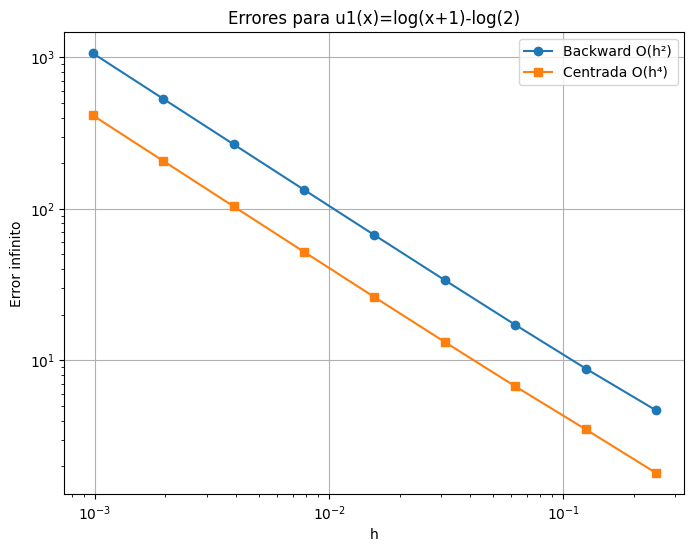

In [10]:
plt.figure(figsize=(8,6))

plt.loglog(
    hs1_b,
    err1_b,
    'o-',
    label='Backward O(h²)'
)

plt.loglog(
    hs1_c,
    err1_c,
    's-',
    label='Centrada O(h⁴)'
)

plt.xlabel("h")
plt.ylabel("Error infinito")

plt.title("Errores para u1(x)=log(x+1)-log(2)")

plt.grid(True)
plt.legend()

plt.savefig("error_u1.png", dpi=300)
plt.show()

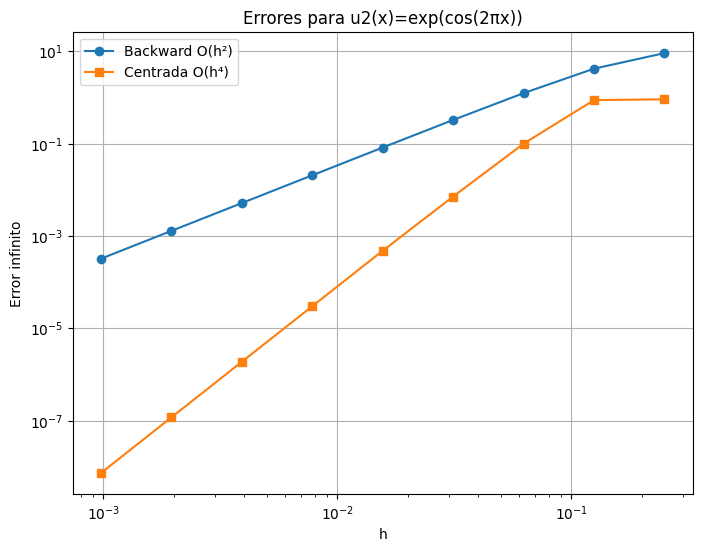

In [11]:
plt.figure(figsize=(8,6))

plt.loglog(
    hs2_b,
    err2_b,
    'o-',
    label='Backward O(h²)'
)

plt.loglog(
    hs2_c,
    err2_c,
    's-',
    label='Centrada O(h⁴)'
)

plt.xlabel("h")
plt.ylabel("Error infinito")

plt.title("Errores para u2(x)=exp(cos(2πx))")

plt.grid(True)
plt.legend()

plt.savefig("error_u2.png", dpi=300)
plt.show()